# 03_UsedCar_FCM — Fuzzy Cognitive Map (Scenario Approach)

**Goal:** Use a Fuzzy Cognitive Map (FCM) to model used-car purchase evaluation under uncertainty.

This notebook models concepts like mileage, age, maintenance quality, seller trust, reliability, repair risk, and value-for-money.
Then we run multiple **scenarios** (what-if settings) and compare outcomes.

In [1]:
from fcmpy import FcmSimulator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1) Define FCM concepts and weight matrix

- Positive weight: increase in concept A increases concept B  
- Negative weight: increase in concept A decreases concept B  
- Values are in [-1, 1] and represent causal strength.

In [2]:
concepts = [
    "MileageHigh",
    "AgeOld",
    "MaintenanceGood",
    "SellerTrust",
    "Reliability",
    "RepairRisk",
    "ValueForMoney",
    "Recommendation"
]

# Initialize a zero matrix
W = pd.DataFrame(
    np.zeros((len(concepts), len(concepts))),
    index=concepts,
    columns=concepts
)

# Causal assumptions (kept small + interpretable)

# High mileage and old age reduce reliability
W.loc["MileageHigh", "Reliability"] = -0.7
W.loc["AgeOld", "Reliability"] = -0.6

# Good maintenance and trusted seller increase reliability
W.loc["MaintenanceGood", "Reliability"] = +0.8
W.loc["SellerTrust", "Reliability"] = +0.4

# Good maintenance reduces repair risk (directly)
W.loc["MaintenanceGood", "RepairRisk"] = -0.5

# Higher reliability reduces repair risk
W.loc["Reliability", "RepairRisk"] = -0.8

# Higher repair risk reduces value-for-money and recommendation
W.loc["RepairRisk", "ValueForMoney"] = -0.6
W.loc["RepairRisk", "Recommendation"] = -0.8

# Value-for-money increases recommendation
W.loc["ValueForMoney", "Recommendation"] = +0.9

# Mileage high and age old often reduce value-for-money (indirectly/roughly)
W.loc["MileageHigh", "ValueForMoney"] = -0.3
W.loc["AgeOld", "ValueForMoney"] = -0.2

# Trusted seller can improve perceived value-for-money a bit
W.loc["SellerTrust", "ValueForMoney"] = +0.2

W

,MileageHigh,AgeOld,MaintenanceGood,SellerTrust,Reliability,RepairRisk,ValueForMoney,Recommendation
MileageHigh,0.0,0.0,0.0,0.0,-0.7,0.0,-0.3,0.0
AgeOld,0.0,0.0,0.0,0.0,-0.6,0.0,-0.2,0.0
MaintenanceGood,0.0,0.0,0.0,0.0,0.8,-0.5,0.0,0.0
SellerTrust,0.0,0.0,0.0,0.0,0.4,0.0,0.2,0.0
Reliability,0.0,0.0,0.0,0.0,0.0,-0.8,0.0,0.0
RepairRisk,0.0,0.0,0.0,0.0,0.0,0.0,-0.6,-0.8
ValueForMoney,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9
Recommendation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2) Run FCM simulation (Scenario approach)

I use `FcmSimulator()` and run multiple "what-if" initial states.
The output shows how concept values evolve across iterations.

In [3]:
sim = FcmSimulator()

def run_scenario(name, init_state, transfer="tanh", inference="mKosko", iterations=30, thresh=0.001, l=1):
    """
    Runs one scenario and returns the simulation result (pandas-like object).
    """
    res = sim.simulate(
        initial_state=init_state,
        weight_matrix=W,
        transfer=transfer,
        inference=inference,
        thresh=thresh,
        iterations=iterations,
        l=l
    )
    return name, res

## 3) Define 3 realistic used-car scenarios

Values are in [0, 1] (low to high).
- MileageHigh = 1 means very high mileage
- MaintenanceGood = 1 means strong service history / well maintained
- SellerTrust = 1 means trusted dealer + transparent documents

In [4]:
scenarios = [
    (
        "A) Trusted seller + good maintenance, but older car",
        {
            "MileageHigh": 0.4,
            "AgeOld": 0.7,
            "MaintenanceGood": 0.9,
            "SellerTrust": 0.9,
            "Reliability": 0.5,
            "RepairRisk": 0.4,
            "ValueForMoney": 0.5,
            "Recommendation": 0.5
        }
    ),
    (
        "B) Very cheap-looking listing: high mileage + weak maintenance signals",
        {
            "MileageHigh": 0.9,
            "AgeOld": 0.8,
            "MaintenanceGood": 0.2,
            "SellerTrust": 0.3,
            "Reliability": 0.5,
            "RepairRisk": 0.5,
            "ValueForMoney": 0.6,
            "Recommendation": 0.5
        }
    ),
    (
        "C) Balanced option: medium mileage, not too old, average maintenance, decent trust",
        {
            "MileageHigh": 0.5,
            "AgeOld": 0.4,
            "MaintenanceGood": 0.6,
            "SellerTrust": 0.7,
            "Reliability": 0.5,
            "RepairRisk": 0.5,
            "ValueForMoney": 0.5,
            "Recommendation": 0.5
        }
    )
]

In [5]:
results = []
for name, init_state in scenarios:
    results.append(run_scenario(name, init_state))

len(results)

The values converged in the 9 state (e <= 0.001)
The values converged in the 9 state (e <= 0.001)
The values converged in the 10 state (e <= 0.001)


3

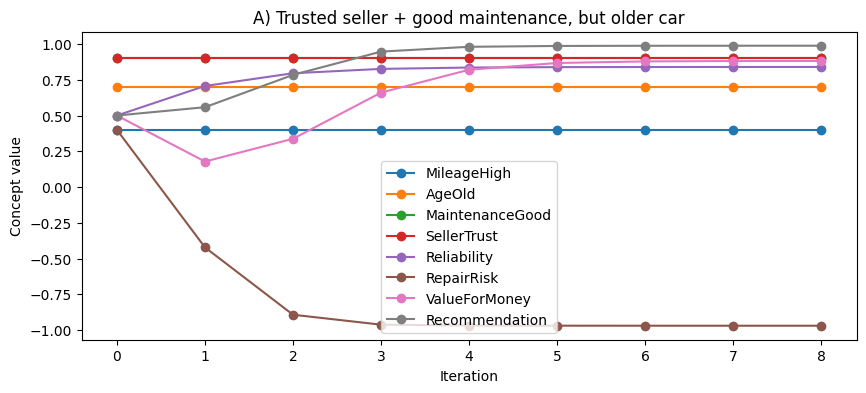

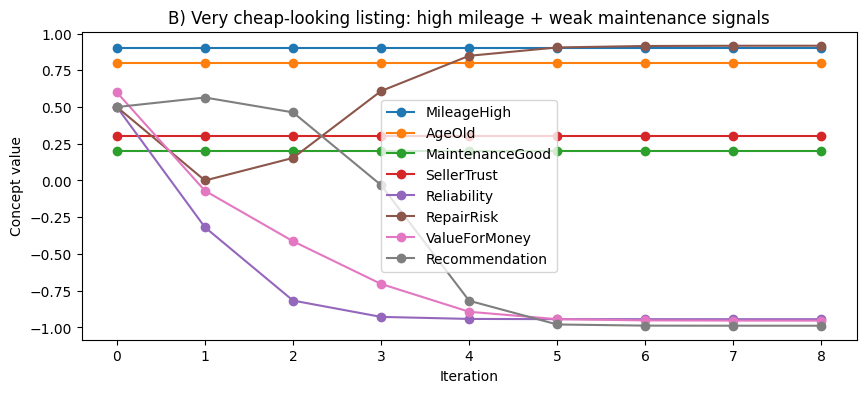

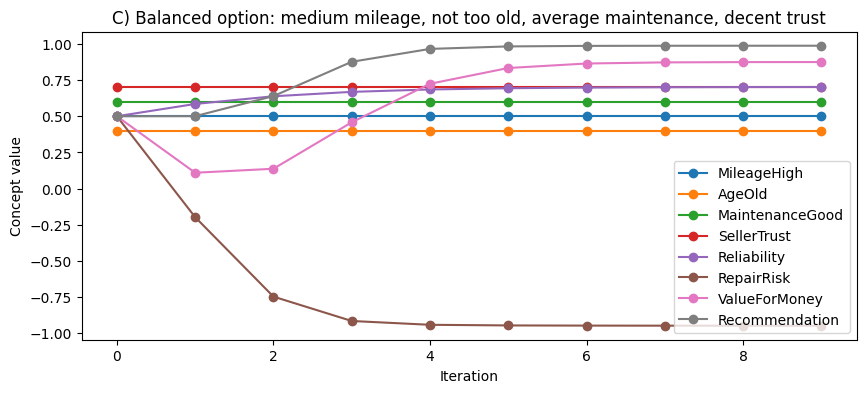

In [6]:
for name, res in results:
    ax = res.plot(marker="o", figsize=(10, 4))
    ax.set_title(name)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Concept value")
    plt.show()

## 4) Compare final outcomes (last iteration)

I compare key outputs:
- Reliability
- RepairRisk
- ValueForMoney
- Recommendation

In [7]:
summary_rows = []
key_cols = ["Reliability", "RepairRisk", "ValueForMoney", "Recommendation"]

for name, res in results:
    last = res.iloc[-1][key_cols]
    summary_rows.append([name] + [float(last[c]) for c in key_cols])

summary = pd.DataFrame(summary_rows, columns=["Scenario"] + key_cols)
summary

,Scenario,Reliability,RepairRisk,ValueForMoney,Recommendation
0,"A) Trusted seller + good maintenance, but olde...",0.839479,-0.969951,0.881622,0.988045
1,B) Very cheap-looking listing: high mileage + ...,-0.944052,0.917405,-0.953959,-0.988596
2,"C) Balanced option: medium mileage, not too ol...",0.702184,-0.947717,0.874708,0.987446


## 5) Short interpretation (human explanation)

I interpret results based on our causal assumptions in the weight matrix:
- Higher MaintenanceGood and SellerTrust should increase Reliability.
- Higher Reliability should reduce RepairRisk.
- Lower RepairRisk should increase Recommendation.

In [8]:
for _, row in summary.iterrows():
    print(row["Scenario"])
    print(f"  Reliability     : {row['Reliability']:.3f}")
    print(f"  RepairRisk      : {row['RepairRisk']:.3f}")
    print(f"  ValueForMoney   : {row['ValueForMoney']:.3f}")
    print(f"  Recommendation  : {row['Recommendation']:.3f}")
    print("-" * 60)

A) Trusted seller + good maintenance, but older car
  Reliability     : 0.839
  RepairRisk      : -0.970
  ValueForMoney   : 0.882
  Recommendation  : 0.988
------------------------------------------------------------
B) Very cheap-looking listing: high mileage + weak maintenance signals
  Reliability     : -0.944
  RepairRisk      : 0.917
  ValueForMoney   : -0.954
  Recommendation  : -0.989
------------------------------------------------------------
C) Balanced option: medium mileage, not too old, average maintenance, decent trust
  Reliability     : 0.702
  RepairRisk      : -0.948
  ValueForMoney   : 0.875
  Recommendation  : 0.987
------------------------------------------------------------


## Conclusion

This notebook demonstrates the **Scenario approach** for FCMs applied to a used-car decision problem.

Key takeaway:
- Scenarios with stronger maintenance and trust signals tend to improve reliability and reduce repair risk,
  which increases the final recommendation score.
